In [1]:
# ============================================================
# Hotel Reviews Sentiment Analysis
# Notebook 2: Machine Learning
# Dataset: La Veranda Hotel - Booking.com Reviews
# ============================================================

# ============================================================
# SECTION 1: Install Libraries
# ============================================================

!pip install nltk
!pip install textblob
!pip install wordcloud
!pip install seaborn
!pip install joblib
!pip install xgboost


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ============================================================
# SECTION 2: Import Libraries
# ============================================================

import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier,
                               GradientBoostingClassifier)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/paco/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/paco/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/paco/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# ============================================================
# SECTION 3: Load Cleaned Dataset
# ============================================================

df = pd.read_csv('Dataset/cleaned/hotel_reviews_cleaned.csv')
df.head()

,Title,PositiveReview,NegativeReview,Score,GuestName,GuestCountry,RoomType,NumberOfNights,VisitDate,GroupType,PropertyResponse,cleaned_positive,cleaned_negative,sentiment,polarity_positive,polarity_negative,visit_month,visit_year
0,Wonderful place to stay.,"New, comfortable apartments, close to the airp...",Nothing at all.,10.0,Olga,Norway,Budget Twin Room,1 night,2022-06-01,Solo traveler,NaN,new comfort apart close airport clean beach st...,noth,positive,0.263258,0.0,6,2022
1,It was superb,We had a really pleasant stay! The staff was v...,NaN,10.0,Iwona,Poland,Double Room,3 nights,2022-12-01,Family,NaN,realli pleasant stay staff nice help room clea...,NaN,positive,0.400000,0.0,12,2022
2,Very Good,the location is great and near the airport. bu...,NaN,8.0,Ruijia,Sweden,Double Room,1 night,2022-12-01,Solo traveler,NaN,locat great near airport bu stop close,NaN,positive,0.450000,0.0,12,2022
3,Wonderful,Great stuff\nGreat Quality/price\nClean,NaN,9.0,Theprincem,United Kingdom,Double Room with Balcony,2 nights,2022-09-01,Solo traveler,NaN,great stuff great qualitypric clean,NaN,positive,0.655556,0.0,9,2022
4,"Fantastic value for a new, modern and spotless...","Clean and modern with very comfortable beds, i...",NaN,10.0,M,Switzerland,Family Suite with Balcony,1 night,2022-10-01,Family,NaN,clean modern comfort bed conveni locat easi st...,NaN,positive,0.491667,0.0,10,2022


In [4]:
# ============================================================
# SECTION 4: Data Validation
# ============================================================

print("Shape:", df.shape)
df.isnull().sum()

Shape: (786, 18)


Title                  0
PositiveReview        11
NegativeReview       352
Score                  0
GuestName              0
GuestCountry           0
RoomType              27
NumberOfNights         0
VisitDate              0
GroupType              0
PropertyResponse     665
cleaned_positive      13
cleaned_negative     362
sentiment              0
polarity_positive      0
polarity_negative      0
visit_month            0
visit_year             0
dtype: int64

In [5]:
df.dropna(subset=['cleaned_positive', 'cleaned_negative', 'sentiment'], inplace=True)
df.isnull().sum()

Title                  0
PositiveReview         0
NegativeReview         0
Score                  0
GuestName              0
GuestCountry           0
RoomType              12
NumberOfNights         0
VisitDate              0
GroupType              0
PropertyResponse     345
cleaned_positive       0
cleaned_negative       0
sentiment              0
polarity_positive      0
polarity_negative      0
visit_month            0
visit_year             0
dtype: int64

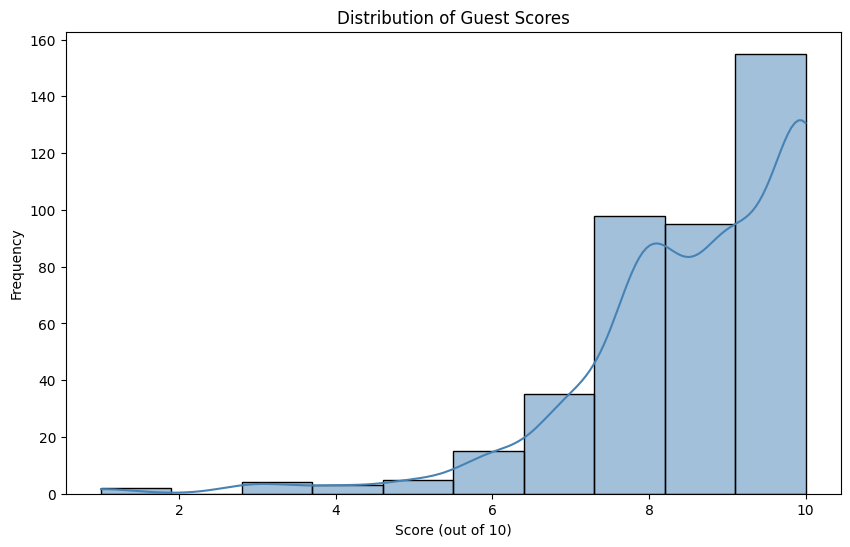

In [6]:
# ============================================================
# SECTION 5: Exploratory Data Analysis
# ============================================================

# --- 5a. Score Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Score'], bins=10, kde=True, color='steelblue')
plt.title('Distribution of Guest Scores')
plt.xlabel('Score (out of 10)')
plt.ylabel('Frequency')
plt.show()

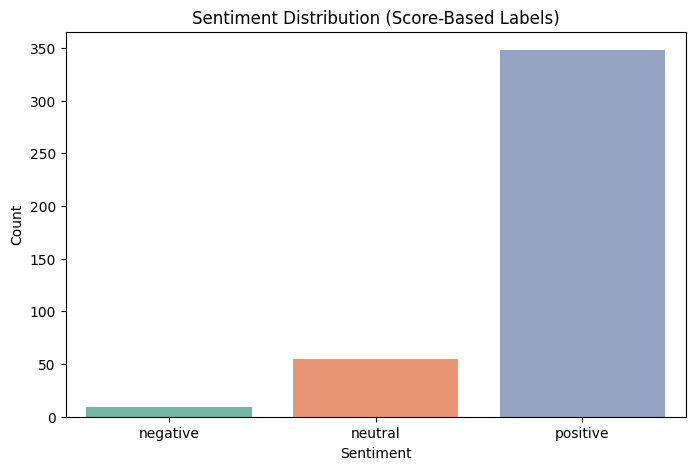

In [7]:
# --- 5b. Sentiment Distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='Set2',
              order=['negative', 'neutral', 'positive'])
plt.title('Sentiment Distribution (Score-Based Labels)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

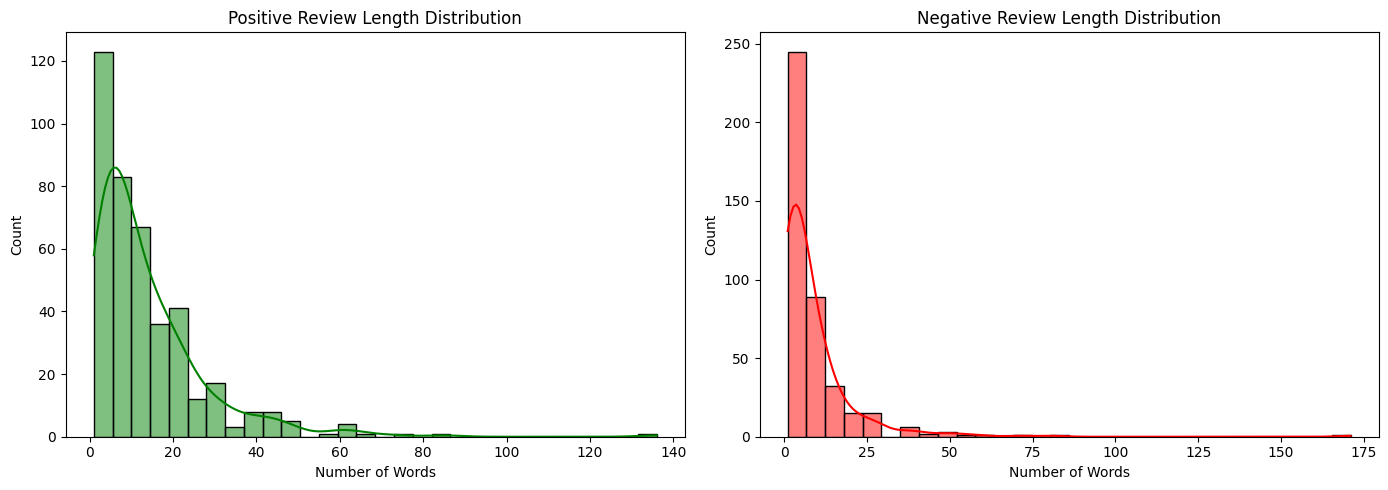

In [8]:
# --- 5c. Review Length Distribution (Positive vs Negative) ---
df['pos_length'] = df['cleaned_positive'].apply(lambda x: len(str(x).split()))
df['neg_length'] = df['cleaned_negative'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['pos_length'], bins=30, kde=True, ax=axes[0], color='green')
axes[0].set_title('Positive Review Length Distribution')
axes[0].set_xlabel('Number of Words')

sns.histplot(df['neg_length'], bins=30, kde=True, ax=axes[1], color='red')
axes[1].set_title('Negative Review Length Distribution')
axes[1].set_xlabel('Number of Words')
plt.tight_layout()
plt.show()

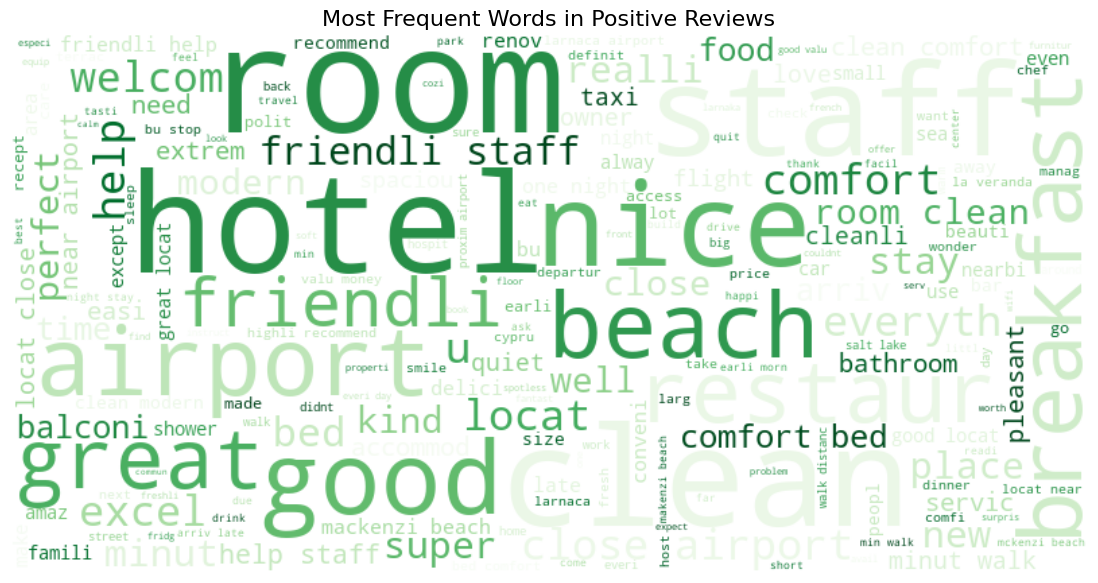

In [9]:
# --- 5d. WordCloud - Positive Reviews ---
pos_words = ' '.join(df['cleaned_positive'].dropna().astype(str))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white',
                          colormap='Greens', max_font_size=110,
                          random_state=42).generate(pos_words)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Reviews', fontsize=16)
plt.show()

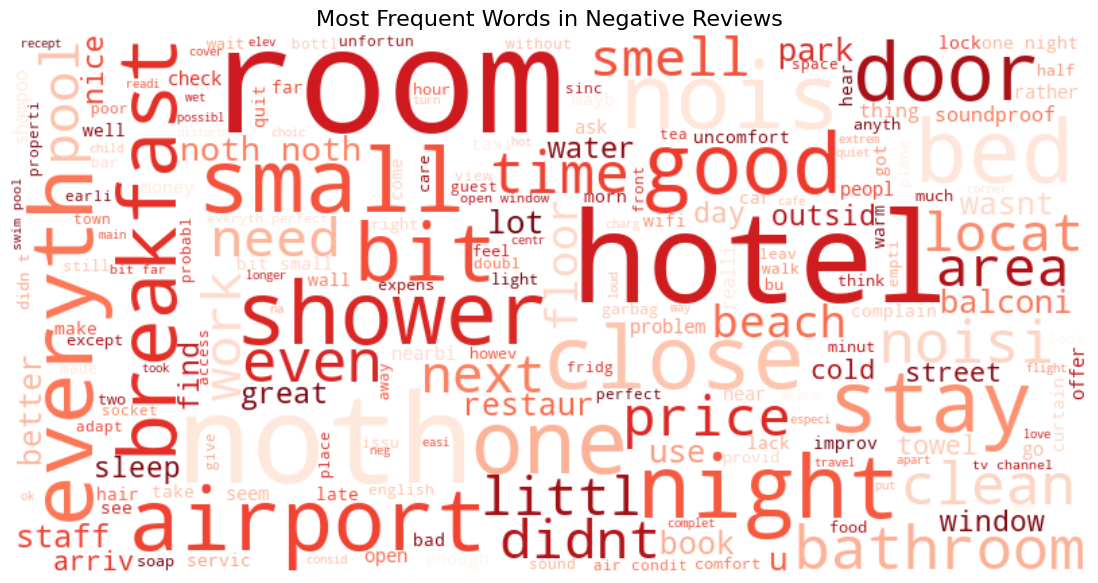

In [10]:
# --- 5e. WordCloud - Negative Reviews ---
neg_words = ' '.join(df['cleaned_negative'].dropna().astype(str))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white',
                          colormap='Reds', max_font_size=110,
                          random_state=42).generate(neg_words)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews', fontsize=16)
plt.show()

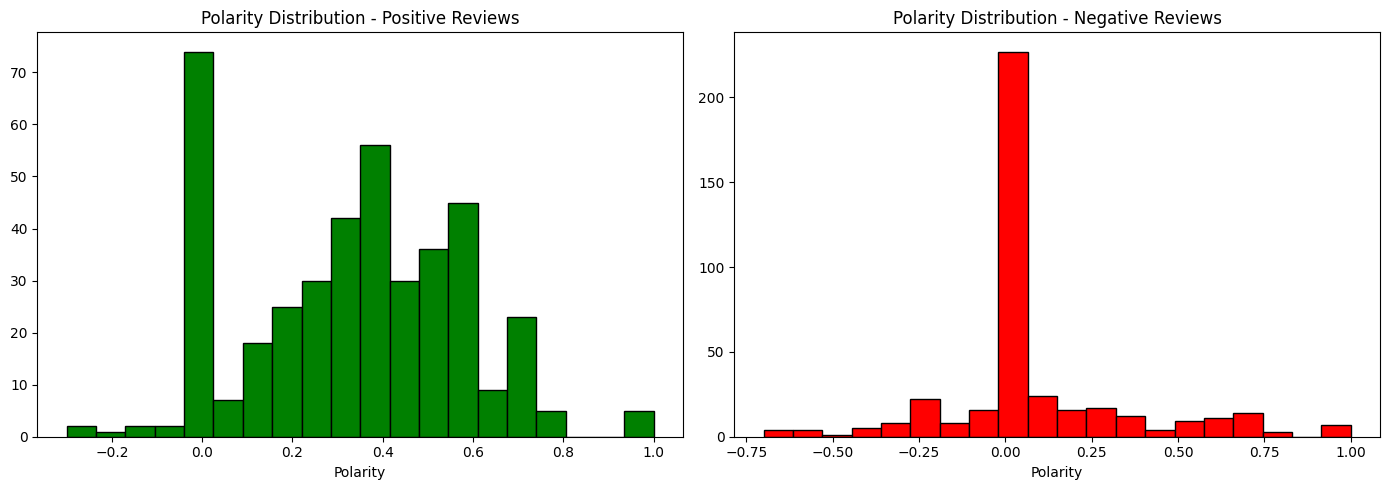

In [11]:
# --- 5f. Polarity Distribution (Positive vs Negative track) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['polarity_positive'], bins=20, color='green', edgecolor='black')
axes[0].set_title('Polarity Distribution - Positive Reviews')
axes[0].set_xlabel('Polarity')

axes[1].hist(df['polarity_negative'], bins=20, color='red', edgecolor='black')
axes[1].set_title('Polarity Distribution - Negative Reviews')
axes[1].set_xlabel('Polarity')
plt.tight_layout()
plt.show()

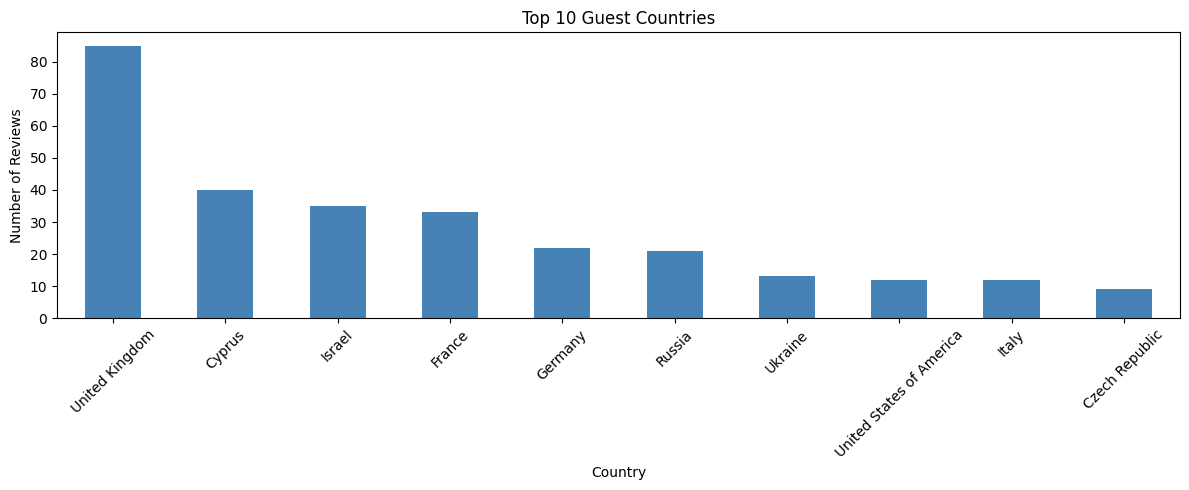

In [12]:
# --- 5g. Top 10 Guest Countries ---
plt.figure(figsize=(12, 5))
df['GuestCountry'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Guest Countries')
plt.xlabel('Country')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

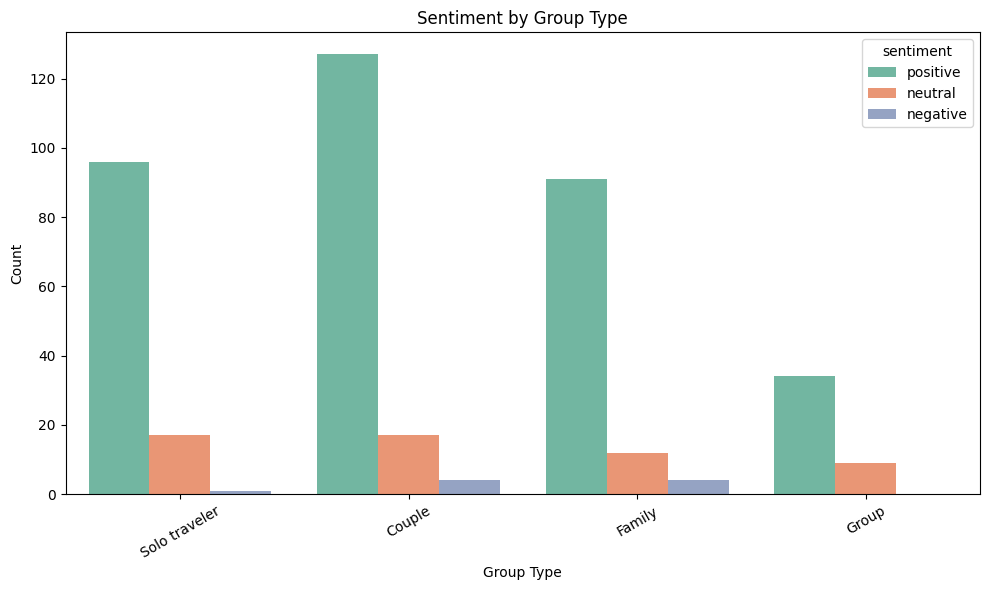

In [13]:
# --- 5h. Sentiment by Group Type ---
plt.figure(figsize=(10, 6))
sns.countplot(x='GroupType', hue='sentiment', data=df, palette='Set2')
plt.title('Sentiment by Group Type')
plt.xlabel('Group Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# SECTION 6: Vectorization & Train/Test Split
# We run two parallel pipelines:
#   Track A — Positive Reviews
#   Track B — Negative Reviews
# ============================================================

# --- Track A: Positive Reviews ---
vectorizer_pos = TfidfVectorizer()
X_pos = vectorizer_pos.fit_transform(df['cleaned_positive'].astype(str))
y = df['sentiment']

X_train_pos, X_test_pos, y_train, y_test = train_test_split(
    X_pos, y, test_size=0.2, random_state=42, stratify=y)

print("Positive Track — Train:", X_train_pos.shape, "| Test:", X_test_pos.shape)

# --- Track B: Negative Reviews ---
vectorizer_neg = TfidfVectorizer()
X_neg = vectorizer_neg.fit_transform(df['cleaned_negative'].astype(str))

X_train_neg, X_test_neg, _, _ = train_test_split(
    X_neg, y, test_size=0.2, random_state=42, stratify=y)

print("Negative Track — Train:", X_train_neg.shape, "| Test:", X_test_neg.shape)

Positive Track — Train: (329, 1006) | Test: (83, 1006)
Negative Track — Train: (329, 1165) | Test: (83, 1165)


In [15]:
# ============================================================
# SECTION 7: Helper Function
# Keeps model training/evaluation clean and DRY
# ============================================================

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    print(f"Evaluation for: {name}".center(65, '_'))
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec  = recall_score(y_test, preds, average='weighted')
    f1   = f1_score(y_test, preds, average='weighted')

    print(f"Accuracy:  {acc:.2%}")
    print(f"Precision: {prec:.2%}")
    print(f"Recall:    {rec:.2%}")
    print(f"F1-Score:  {f1:.2%}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.0f', linewidths=0.7,
                square=True, cmap='Blues_r',
                xticklabels=['negative','neutral','positive'],
                yticklabels=['negative','neutral','positive'])
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print(f"Classification Report — {name}:")
    print('-' * 65)
    print(classification_report(y_test, preds))

    return model, preds, [acc*100, prec*100, rec*100, f1*100]

In [16]:
!pip install threadpoolctl --upgrade


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip



  POSITIVE REVIEW TRACK — Logistic Regression
_______________Evaluation for: Logistic Regression_______________
Accuracy:  84.34%
Precision: 71.13%
Recall:    84.34%
F1-Score:  77.17%


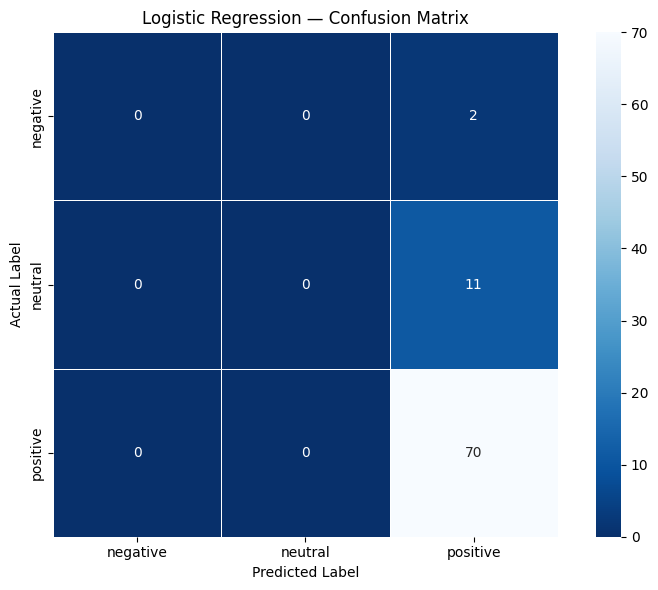

Classification Report — Logistic Regression:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      1.00      0.92        70

    accuracy                           0.84        83
   macro avg       0.28      0.33      0.31        83
weighted avg       0.71      0.84      0.77        83


  NEGATIVE REVIEW TRACK — Logistic Regression
_______________Evaluation for: Logistic Regression_______________
Accuracy:  84.34%
Precision: 71.13%
Recall:    84.34%
F1-Score:  77.17%


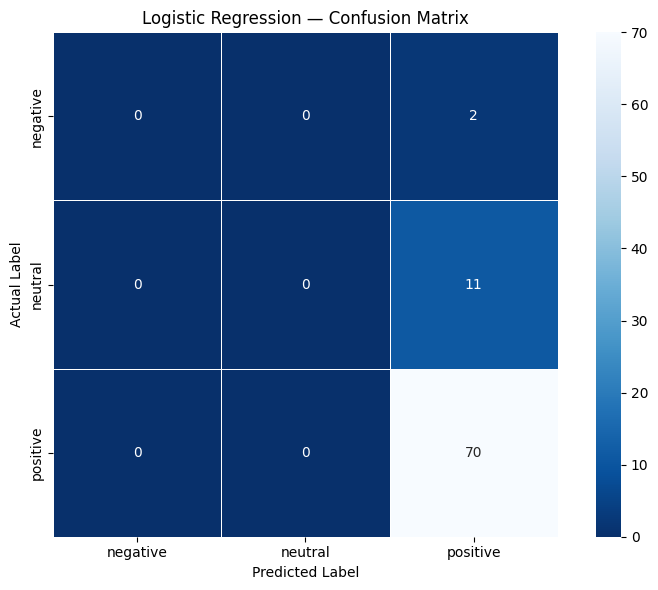

Classification Report — Logistic Regression:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      1.00      0.92        70

    accuracy                           0.84        83
   macro avg       0.28      0.33      0.31        83
weighted avg       0.71      0.84      0.77        83


  POSITIVE REVIEW TRACK — AdaBoost
_____________________Evaluation for: AdaBoost____________________
Accuracy:  84.34%
Precision: 71.13%
Recall:    84.34%
F1-Score:  77.17%


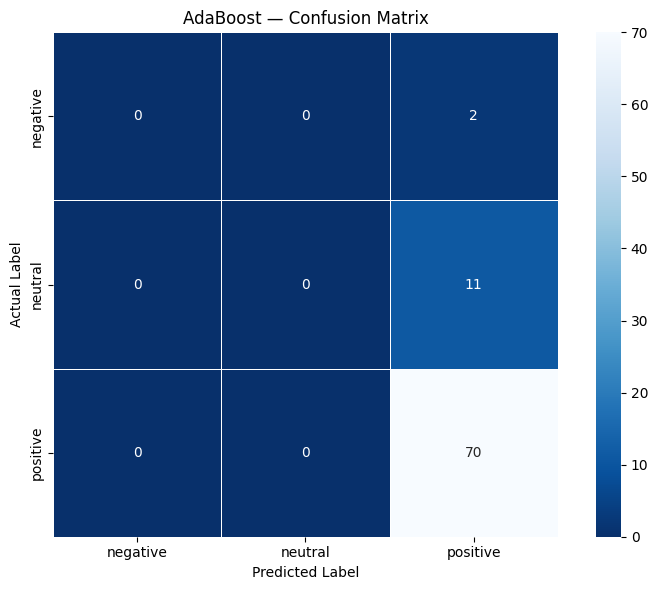

Classification Report — AdaBoost:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      1.00      0.92        70

    accuracy                           0.84        83
   macro avg       0.28      0.33      0.31        83
weighted avg       0.71      0.84      0.77        83


  NEGATIVE REVIEW TRACK — AdaBoost
_____________________Evaluation for: AdaBoost____________________
Accuracy:  79.52%
Precision: 73.40%
Recall:    79.52%
F1-Score:  76.14%


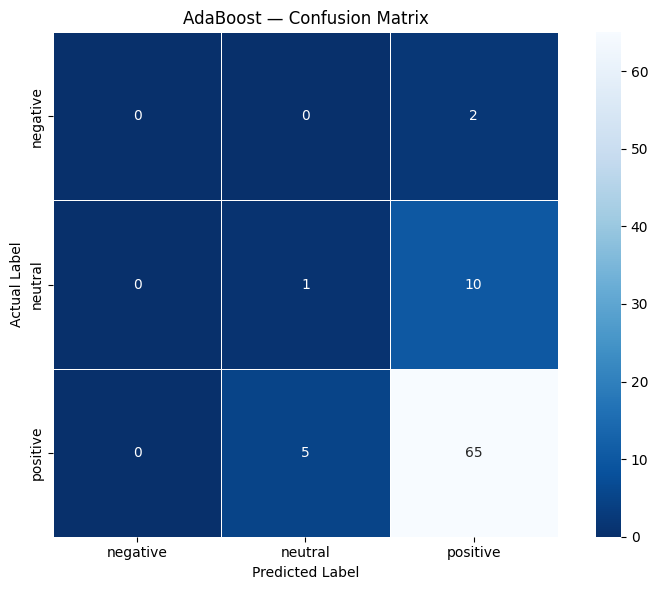

Classification Report — AdaBoost:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.17      0.09      0.12        11
    positive       0.84      0.93      0.88        70

    accuracy                           0.80        83
   macro avg       0.34      0.34      0.33        83
weighted avg       0.73      0.80      0.76        83


  POSITIVE REVIEW TRACK — Decision Tree
__________________Evaluation for: Decision Tree__________________
Accuracy:  83.13%
Precision: 70.97%
Recall:    83.13%
F1-Score:  76.57%


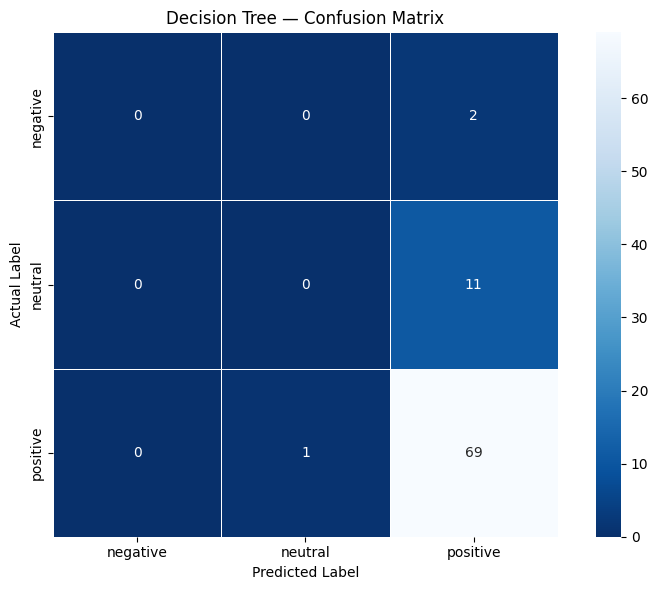

Classification Report — Decision Tree:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      0.99      0.91        70

    accuracy                           0.83        83
   macro avg       0.28      0.33      0.30        83
weighted avg       0.71      0.83      0.77        83


  NEGATIVE REVIEW TRACK — Decision Tree
__________________Evaluation for: Decision Tree__________________
Accuracy:  73.49%
Precision: 74.15%
Recall:    73.49%
F1-Score:  73.80%


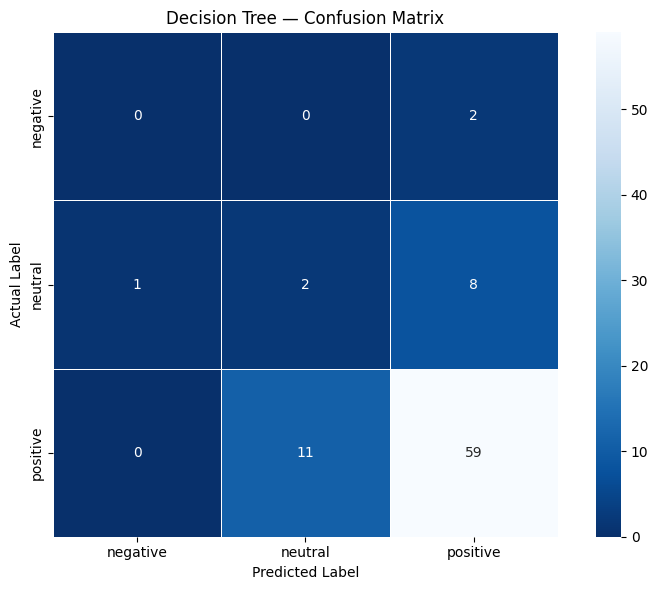

Classification Report — Decision Tree:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.15      0.18      0.17        11
    positive       0.86      0.84      0.85        70

    accuracy                           0.73        83
   macro avg       0.34      0.34      0.34        83
weighted avg       0.74      0.73      0.74        83


  POSITIVE REVIEW TRACK — Random Forest
__________________Evaluation for: Random Forest__________________
Accuracy:  84.34%
Precision: 71.13%
Recall:    84.34%
F1-Score:  77.17%


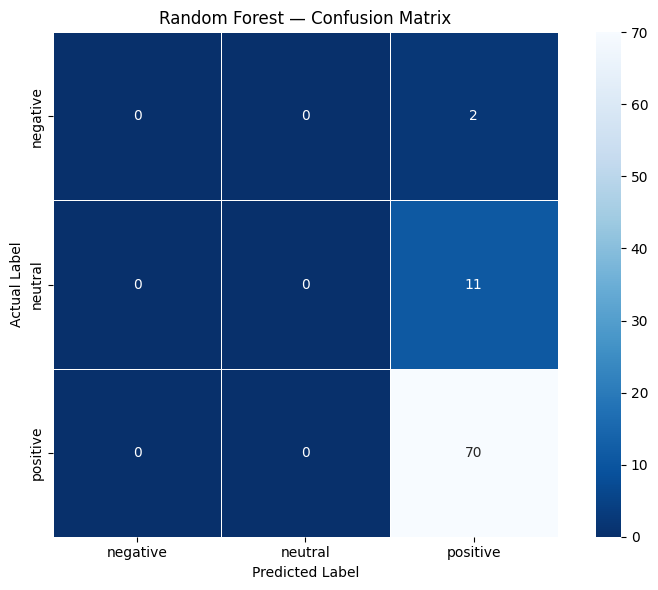

Classification Report — Random Forest:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      1.00      0.92        70

    accuracy                           0.84        83
   macro avg       0.28      0.33      0.31        83
weighted avg       0.71      0.84      0.77        83


  NEGATIVE REVIEW TRACK — Random Forest
__________________Evaluation for: Random Forest__________________
Accuracy:  84.34%
Precision: 71.13%
Recall:    84.34%
F1-Score:  77.17%


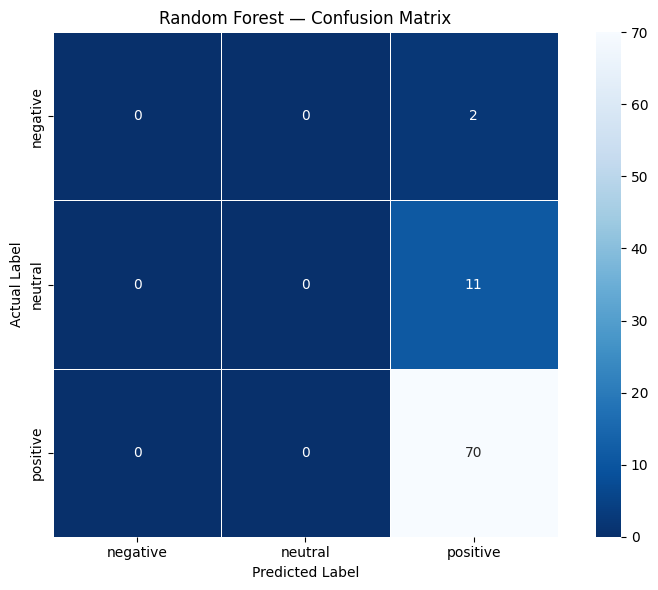

Classification Report — Random Forest:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      1.00      0.92        70

    accuracy                           0.84        83
   macro avg       0.28      0.33      0.31        83
weighted avg       0.71      0.84      0.77        83


  POSITIVE REVIEW TRACK — Gradient Boosting
________________Evaluation for: Gradient Boosting________________
Accuracy:  84.34%
Precision: 71.13%
Recall:    84.34%
F1-Score:  77.17%


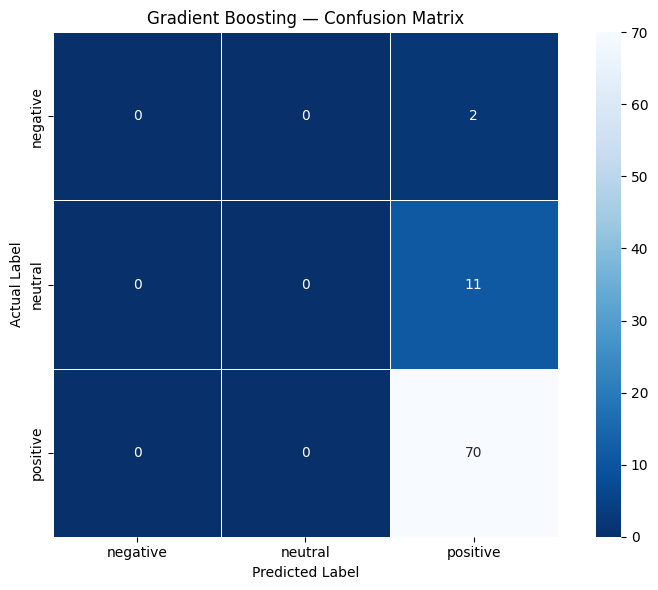

Classification Report — Gradient Boosting:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      1.00      0.92        70

    accuracy                           0.84        83
   macro avg       0.28      0.33      0.31        83
weighted avg       0.71      0.84      0.77        83


  NEGATIVE REVIEW TRACK — Gradient Boosting
________________Evaluation for: Gradient Boosting________________
Accuracy:  77.11%
Precision: 75.27%
Recall:    77.11%
F1-Score:  76.17%


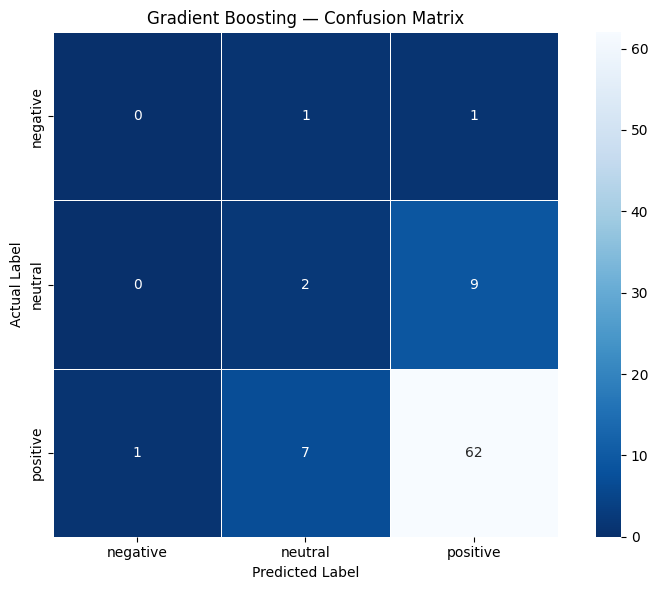

Classification Report — Gradient Boosting:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.20      0.18      0.19        11
    positive       0.86      0.89      0.87        70

    accuracy                           0.77        83
   macro avg       0.35      0.36      0.35        83
weighted avg       0.75      0.77      0.76        83


  POSITIVE REVIEW TRACK — C-Support Vector
_________________Evaluation for: C-Support Vector________________
Accuracy:  84.34%
Precision: 71.13%
Recall:    84.34%
F1-Score:  77.17%


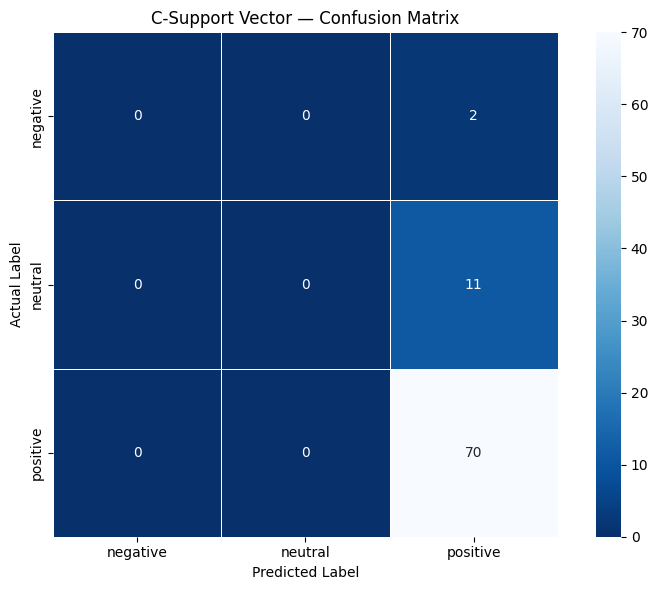

Classification Report — C-Support Vector:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      1.00      0.92        70

    accuracy                           0.84        83
   macro avg       0.28      0.33      0.31        83
weighted avg       0.71      0.84      0.77        83


  NEGATIVE REVIEW TRACK — C-Support Vector
_________________Evaluation for: C-Support Vector________________
Accuracy:  84.34%
Precision: 71.13%
Recall:    84.34%
F1-Score:  77.17%


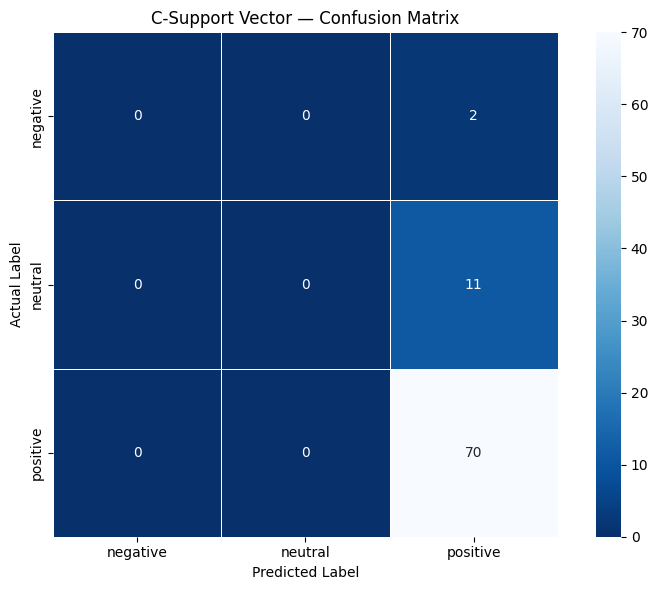

Classification Report — C-Support Vector:
-----------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00        11
    positive       0.84      1.00      0.92        70

    accuracy                           0.84        83
   macro avg       0.28      0.33      0.31        83
weighted avg       0.71      0.84      0.77        83



In [17]:
# ============================================================
# SECTION 8: Train All Models
# Each model is trained on BOTH tracks separately
# ============================================================

models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000),
    'AdaBoost':               AdaBoostClassifier(),
    'Decision Tree':          DecisionTreeClassifier(),
    'Random Forest':          RandomForestClassifier(),
    'Gradient Boosting':      GradientBoostingClassifier(),
    'C-Support Vector':       SVC(),
}

scores_pos = {}
scores_neg = {}
trained_pos = {}
trained_neg = {}

for name, model_blueprint in models.items():
    import copy
    print("\n" + "="*65)
    print(f"  POSITIVE REVIEW TRACK — {name}")
    print("="*65)
    m_pos, _, s_pos = evaluate_model(
        name, copy.deepcopy(model_blueprint),
        X_train_pos, X_test_pos, y_train, y_test)
    trained_pos[name] = m_pos
    scores_pos[name] = s_pos

    print("\n" + "="*65)
    print(f"  NEGATIVE REVIEW TRACK — {name}")
    print("="*65)
    m_neg, _, s_neg = evaluate_model(
        name, copy.deepcopy(model_blueprint),
        X_train_neg, X_test_neg, y_train, y_test)
    trained_neg[name] = m_neg
    scores_neg[name] = s_neg

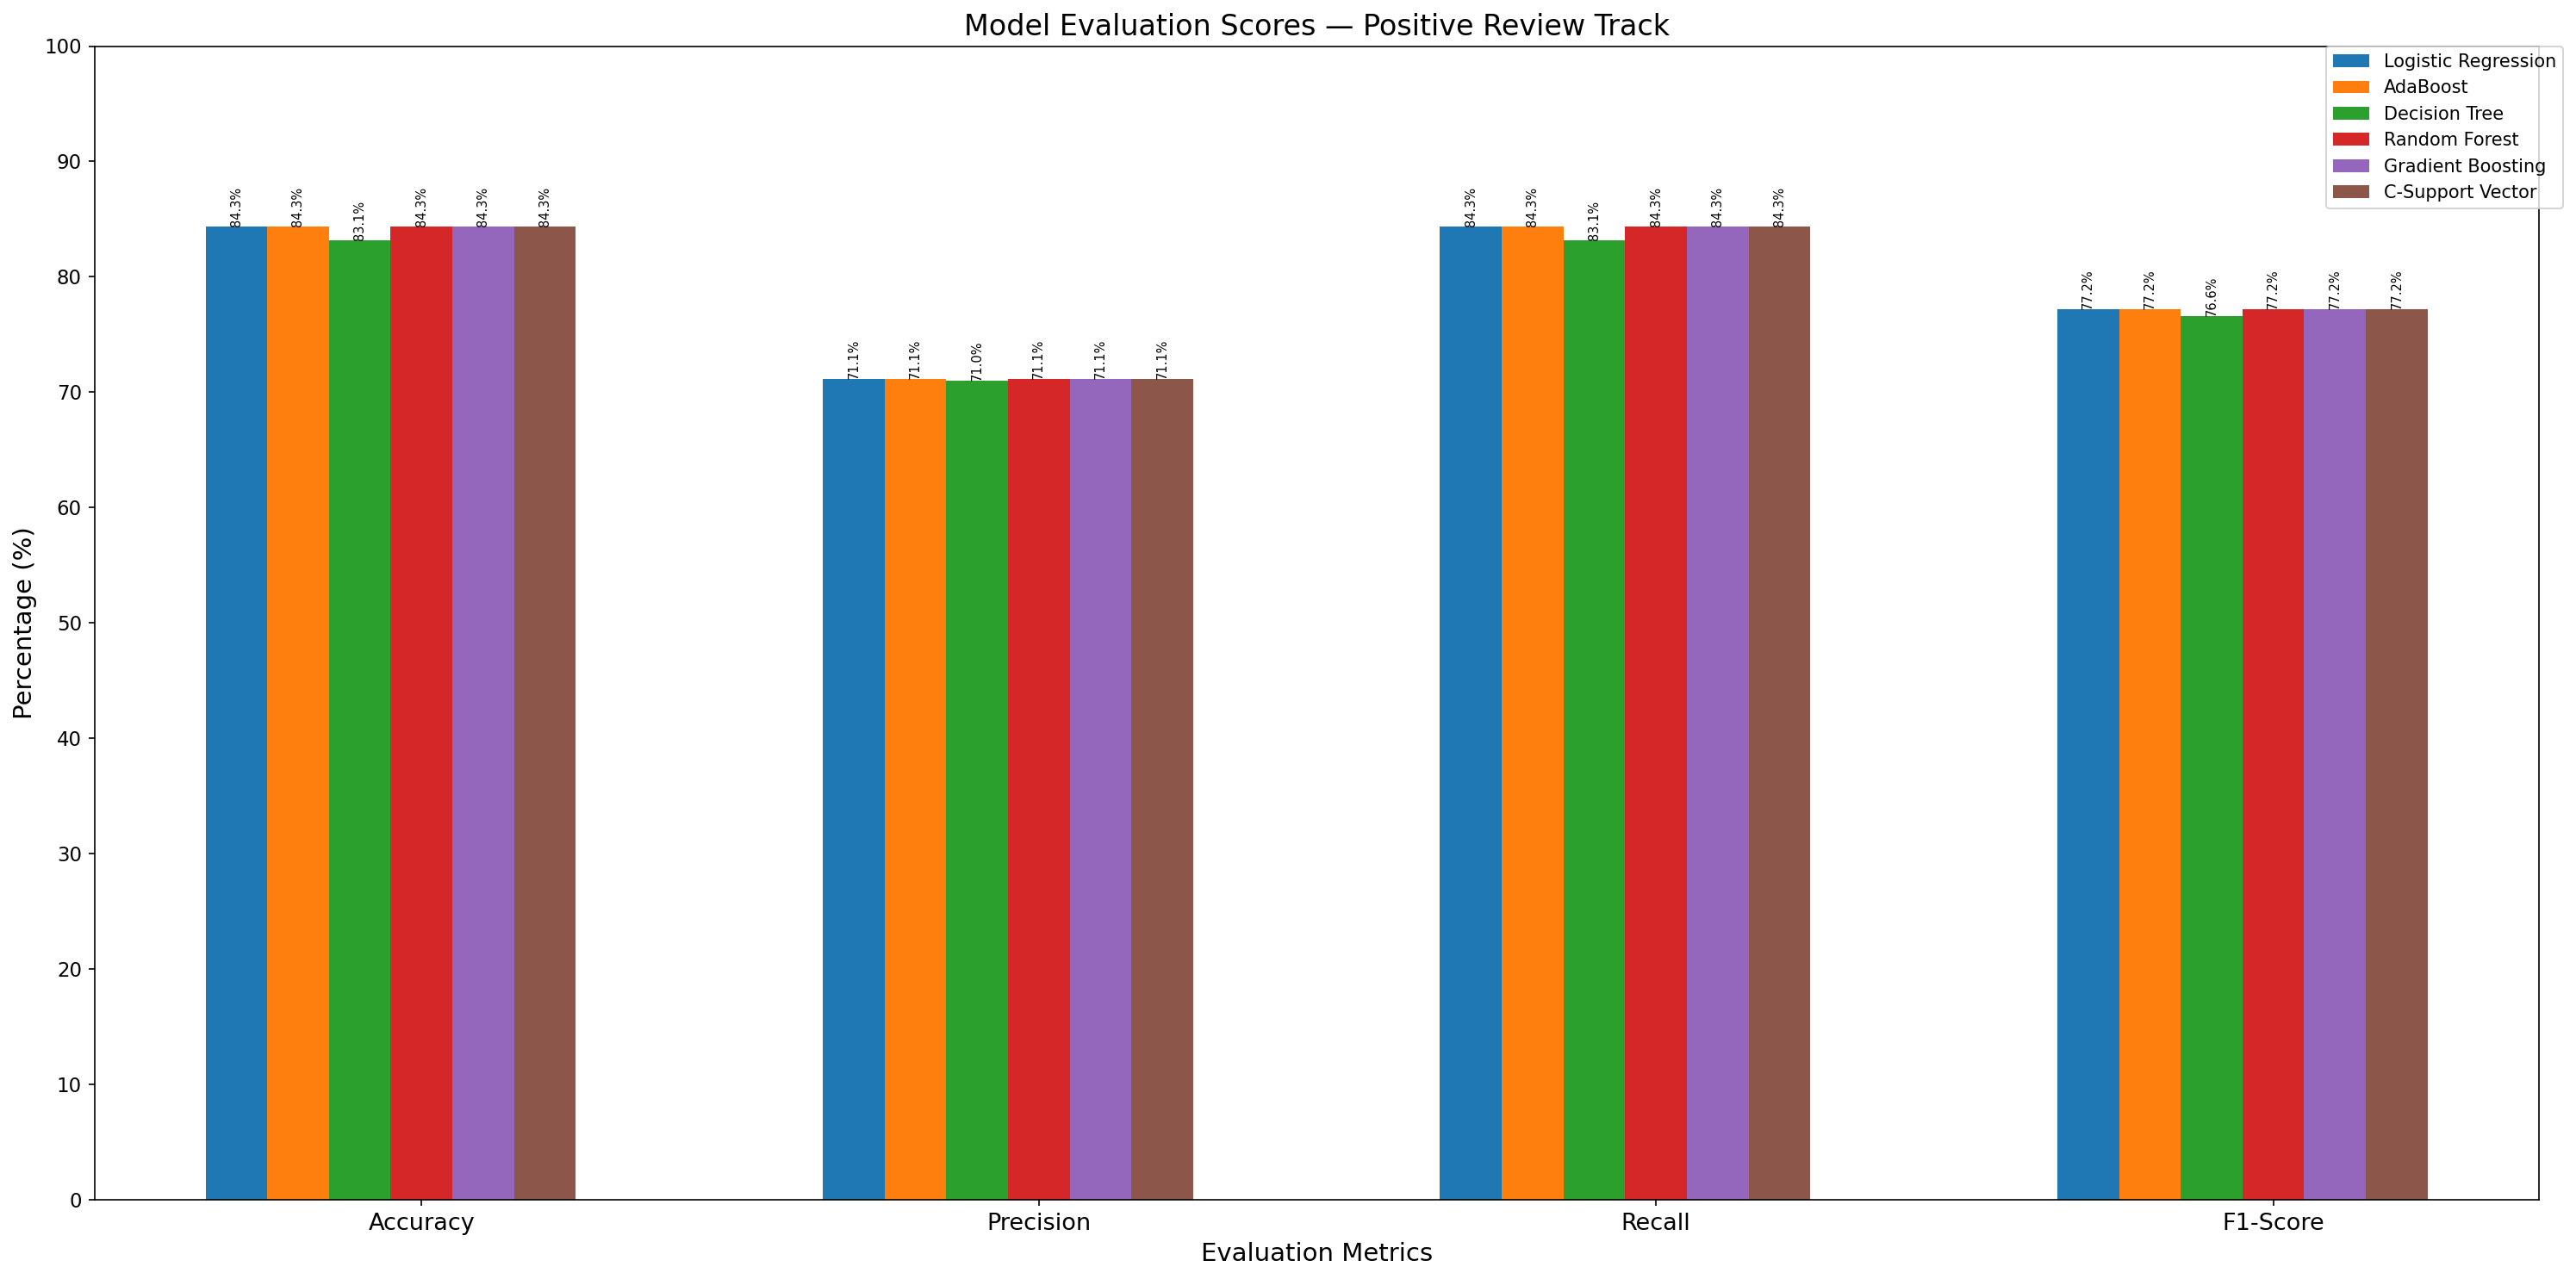

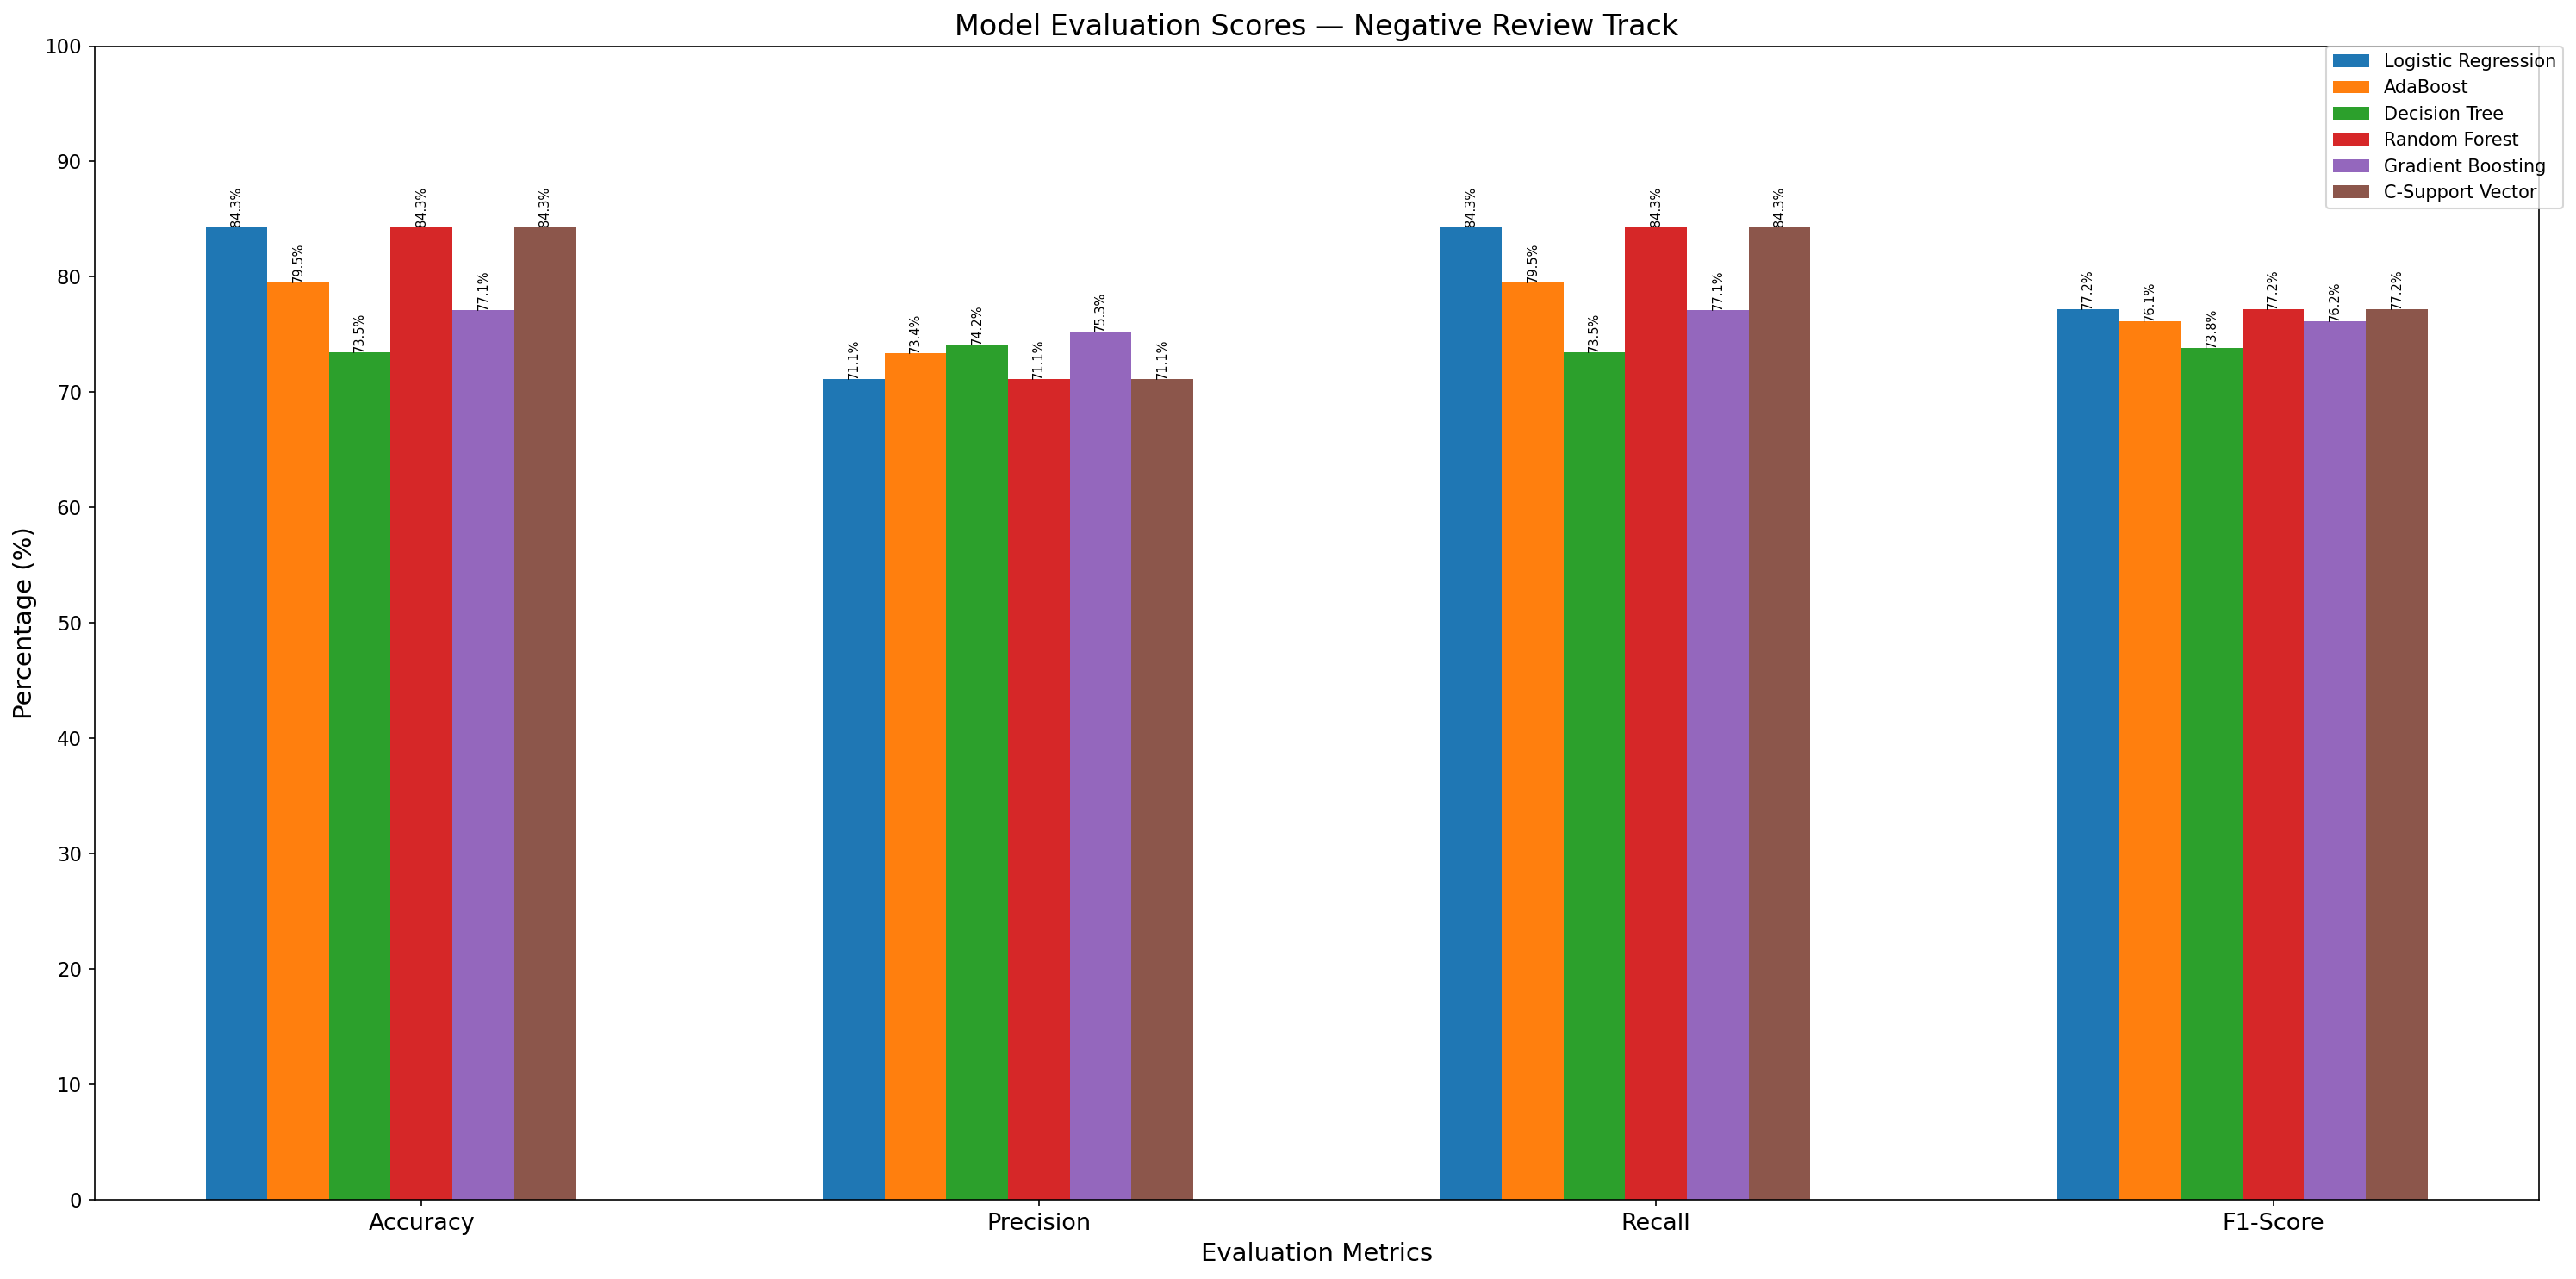

In [18]:
# ============================================================
# SECTION 9: Model Comparison Chart
# ============================================================

def plot_model_comparison(scores_dict, track_name):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    model_names = list(scores_dict.keys())
    x_pos = np.arange(len(metrics))
    bar_width = 0.10

    def add_labels(bars):
        for bar in bars:
            h = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, h,
                     f'{h:.1f}%', ha='center', va='bottom',
                     rotation=90, fontsize=7)

    plt.figure(figsize=(20, 10), dpi=150, facecolor='w')
    plt.title(f"Model Evaluation Scores — {track_name}", fontsize=16)

    for i, name in enumerate(model_names):
        bars = plt.bar(x_pos + bar_width * i, scores_dict[name],
                       width=bar_width, label=name)
        add_labels(bars)

    plt.xticks(x_pos + bar_width * (len(model_names)/2), metrics, fontsize=13)
    plt.yticks(range(0, 110, 10), fontsize=11)
    plt.xlabel('Evaluation Metrics', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.legend(bbox_to_anchor=(1.01, 1), borderaxespad=0.)
    plt.tight_layout()
    plt.show()

plot_model_comparison(scores_pos, 'Positive Review Track')
plot_model_comparison(scores_neg, 'Negative Review Track')

In [19]:
# ============================================================
# SECTION 10: Save Best Models & Vectorizers
# ============================================================

import os
os.makedirs('Models', exist_ok=True)

# Save all models for both tracks
for name, model in trained_pos.items():
    fname = name.lower().replace(' ', '_').replace('-', '')
    joblib.dump(model, f'Models/{fname}_positive.pkl')

for name, model in trained_neg.items():
    fname = name.lower().replace(' ', '_').replace('-', '')
    joblib.dump(model, f'Models/{fname}_negative.pkl')

# Save vectorizers
joblib.dump(vectorizer_pos, 'Models/tfidf_vectorizer_positive.pkl')
joblib.dump(vectorizer_neg, 'Models/tfidf_vectorizer_negative.pkl')

print("All models and vectorizers saved to Models/")

All models and vectorizers saved to Models/
